In [2]:
import numpy as np
import matplotlib.pyplot as plt

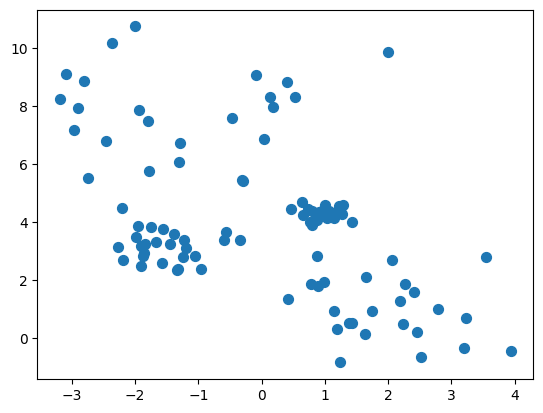

In [3]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=100, centers=4, random_state=0, cluster_std=[0.2, 1, 0.5, 1.5])

plt.scatter(X[:, 0], X[:, 1], s=50);

[3 0 3 3 3 3 1 0 3 0 3 1 0 0 0 2 3 1 1 2 3 0 1 2 3 1 1 3 2 2 2 3 2 2 1 3 0
 2 0 1 3 1 1 1 1 0 2 1 3 3 3 2 1 1 1 0 0 2 2 0 0 2 2 3 2 0 1 1 2 3 0 2 3 0
 3 3 1 1 2 2 2 0 1 3 2 1 2 2 3 3 3 1 3 1 1 0 0 1 0 3]
<function get_cmap at 0x00000248ECD66160>


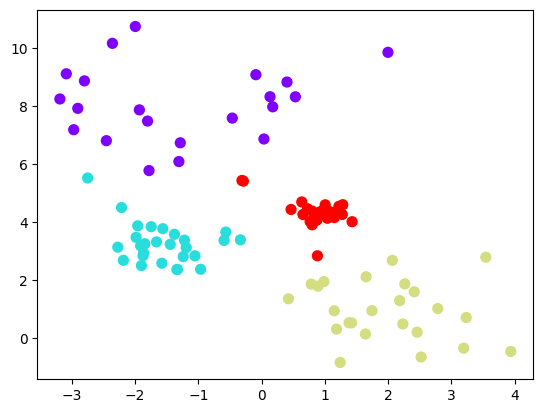

In [4]:
from sklearn.cluster import KMeans

est = KMeans(4, n_init='auto')  # 4 clusters
est.fit(X)
y_kmeans = est.predict(X)
print(y_kmeans)
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='rainbow');
print(plt.get_cmap)

# K-means stap voor stap

## Initialiseer centroiden

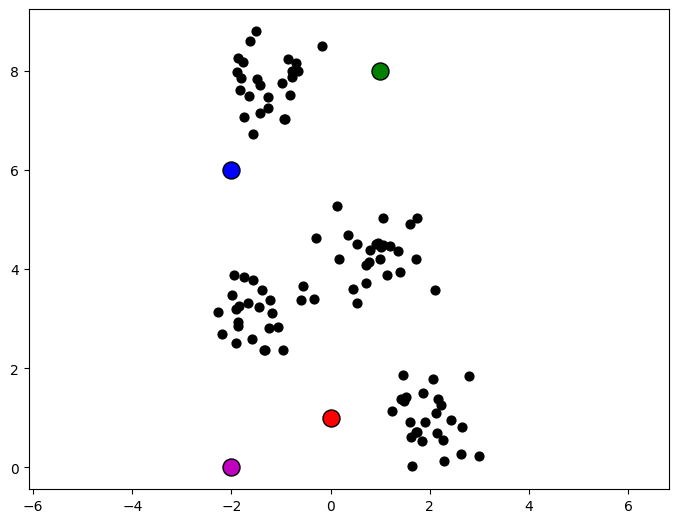

In [15]:
c0 = np.array([0.0,1.0])
c1 = np.array([-2.0,6.0])
c2 = np.array([1.0,8.0])
c3 = np.array([-2.0,0.0])

fig_kmeans = plt.figure()
ax_kmeans = fig_kmeans.add_axes([0,0,1,1])
ax_kmeans.axis('equal')
#ax_kmeans.scatter(X[:, 0], X[:, 1], s=4)
plt.scatter(X[:, 0], X[:, 1], c='k',s=40);
plt.scatter(c0[0],c0[1], c='r',s=150,marker="o",edgecolor='k',linewidths=1)
plt.scatter(c1[0],c1[1], c='b',s=150,marker="o",edgecolor='k',linewidths=1)
plt.scatter(c2[0],c2[1], c='g',s=150,marker="o",edgecolor='k',linewidths=1)
plt.scatter(c3[0],c3[1], c='m',s=150,marker="o",edgecolor='k',linewidths=1)

## Toekennen van punten aan een centroide
Berekening via de Euclidische afstand van elk punt tot een centroide


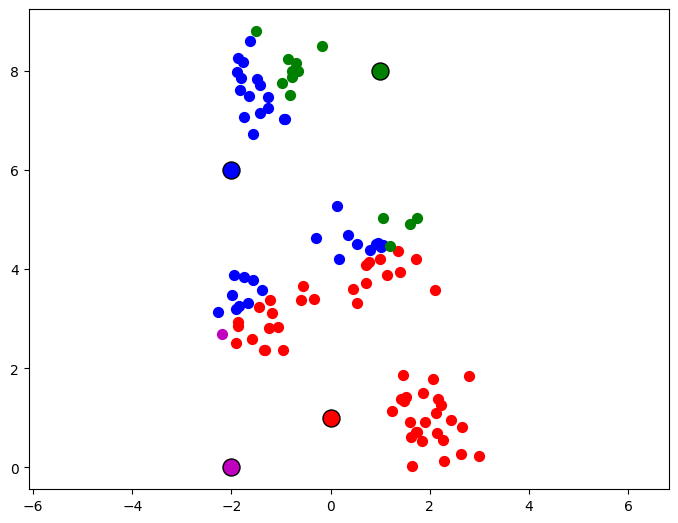

In [16]:
d = np.zeros(4)
y_kmeans = np.zeros(len(X))
x0 = X[:,0]
x1 = X[:,1]

for n in range(0,len(X)):
    d[0]= np.sqrt((c0[0]-x0[n])**2 + (c0[1]-x1[n])**2)
    d[1]= np.sqrt((c1[0]-x0[n])**2 + (c1[1]-x1[n])**2)
    d[2]= np.sqrt((c2[0]-x0[n])**2 + (c2[1]-x1[n])**2)
    d[3]= np.sqrt((c3[0]-x0[n])**2 + (c3[1]-x1[n])**2)
    #print(d)
    y_kmeans[n]=np.argmin(d)
    #print(y_kmeans[n].astype('int'))
y_kmeans = y_kmeans.astype('int')   
#print(y_kmeans)

class0 = (y_kmeans==0)
class1 = (y_kmeans==1)
class2 = (y_kmeans==2)
class3 = (y_kmeans==3)

fig_kmeans = plt.figure()
ax_kmeans = fig_kmeans.add_axes([0,0,1,1])
#ax_kmeans.set_xlim([-3,10])
#ax_kmeans.set_ylim([-3,10])
ax_kmeans.axis('equal')
ax_kmeans.scatter(x0[class0],x1[class0],c='r',s=50,label='class0')
ax_kmeans.scatter(x0[class1],x1[class1],c='b',s=50,label='class1')
ax_kmeans.scatter(x0[class2],x1[class2],c='g',s=50,label='class2')
ax_kmeans.scatter(x0[class3],x1[class3],c='m',s=50,label='class3')

plt.scatter(c0[0],c0[1], c='r',s=150,marker="o",edgecolor='k',linewidths=1)
plt.scatter(c1[0],c1[1], c='b',s=150,marker="o",edgecolor='k',linewidths=1)
plt.scatter(c2[0],c2[1], c='g',s=150,marker="o",edgecolor='k',linewidths=1)
plt.scatter(c3[0],c3[1], c='m',s=150,marker="o",edgecolor='k',linewidths=1)

## Bereken de nieuwe locaties van de centroiden en itereer vorige stappen
Locatie = gemiddelde van alle toegewezen punten tot de centroïde


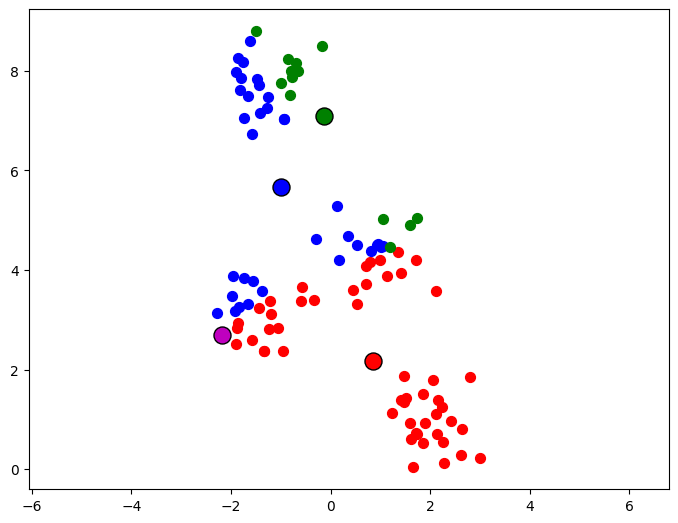

In [17]:
# nieuwe locatie van de centroïden
c0 = [np.mean(x0[class0]),np.mean(x1[class0])]
c1 = [np.mean(x0[class1]),np.mean(x1[class1])]
c2 = [np.mean(x0[class2]),np.mean(x1[class2])]
c3 = [np.mean(x0[class3]),np.mean(x1[class3])]

class0 = (y_kmeans==0)
class1 = (y_kmeans==1)
class2 = (y_kmeans==2)
class3 = (y_kmeans==3)

fig_kmeans = plt.figure()
ax_kmeans = fig_kmeans.add_axes([0,0,1,1])
ax_kmeans.axis('equal')
x0 = X[:, 0]
x1 = X[:, 1]
ax_kmeans.scatter(x0[class0],x1[class0] ,c='r',s=50,label='class0')
ax_kmeans.scatter(x0[class1],x1[class1] ,c='b',s=50,label='class1')
ax_kmeans.scatter(x0[class2],x1[class2] ,c='g',s=50,label='class2')
ax_kmeans.scatter(x0[class3],x1[class3] ,c='m',s=50,label='class3')

plt.scatter(c0[0],c0[1], c='r',s=150,marker="o",edgecolor='k',linewidths=1)
plt.scatter(c1[0],c1[1], c='b',s=150,marker="o",edgecolor='k',linewidths=1)
plt.scatter(c2[0],c2[1], c='g',s=150,marker="o",edgecolor='k',linewidths=1)
plt.scatter(c3[0],c3[1], c='m',s=150,marker="o",edgecolor='k',linewidths=1)

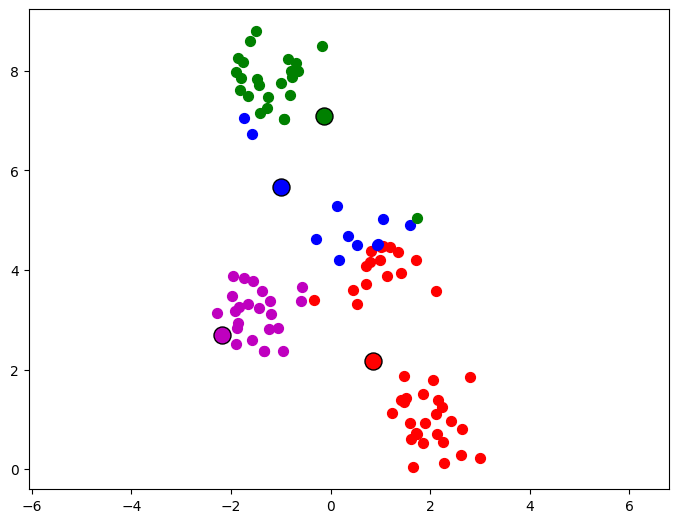

In [18]:
# Euclidische afstand bepalen en punten aan centroiden toewijzen

for n in range(0,len(X)):
    d[0]= np.sqrt((c0[0]-x0[n])**2 + (c0[1]-x1[n])**2)
    d[1]= np.sqrt((c1[0]-x0[n])**2 + (c1[1]-x1[n])**2)
    d[2]= np.sqrt((c2[0]-x0[n])**2 + (c2[1]-x1[n])**2)
    d[3]= np.sqrt((c3[0]-x0[n])**2 + (c3[1]-x1[n])**2)
    y_kmeans[n]=np.argmin(d)
    
y_kmeans = y_kmeans.astype('int')   


class0 = (y_kmeans==0)
class1 = (y_kmeans==1)
class2 = (y_kmeans==2)
class3 = (y_kmeans==3)

fig_kmeans = plt.figure()
ax_kmeans = fig_kmeans.add_axes([0,0,1,1])
ax_kmeans.axis('equal')
x0 = X[:, 0]
x1 = X[:, 1]
ax_kmeans.scatter(x0[class0],x1[class0] ,c='r',s=50,label='class0')
ax_kmeans.scatter(x0[class1],x1[class1] ,c='b',s=50,label='class1')
ax_kmeans.scatter(x0[class2],x1[class2] ,c='g',s=50,label='class2')
ax_kmeans.scatter(x0[class3],x1[class3] ,c='m',s=50,label='class3')

plt.scatter(c0[0],c0[1], c='r',s=150,marker="o",edgecolor='k',linewidths=1)
plt.scatter(c1[0],c1[1], c='b',s=150,marker="o",edgecolor='k',linewidths=1)
plt.scatter(c2[0],c2[1], c='g',s=150,marker="o",edgecolor='k',linewidths=1)
plt.scatter(c3[0],c3[1], c='m',s=150,marker="o",edgecolor='k',linewidths=1)

# PCA? met SKlearn

In [19]:
from sklearn.cluster import KMeans

In [5]:
kmeans = KMeans(n_clusters=4, random_state=0, n_init='auto').fit(X)
kmeans.labels_

array([3, 1, 3, 3, 3, 3, 0, 1, 3, 1, 3, 0, 1, 1, 1, 2, 3, 0, 0, 2, 3, 1,
       0, 2, 3, 0, 0, 3, 2, 2, 2, 3, 2, 2, 0, 3, 1, 2, 1, 0, 3, 0, 0, 0,
       0, 1, 2, 0, 3, 3, 3, 2, 0, 0, 0, 1, 1, 2, 2, 1, 1, 2, 2, 3, 2, 1,
       0, 0, 2, 3, 1, 2, 3, 1, 3, 3, 0, 0, 2, 2, 2, 1, 0, 3, 2, 0, 2, 2,
       3, 3, 3, 0, 3, 0, 0, 1, 1, 0, 1, 3], dtype=int32)

Text(0.5, 1.0, 'Unequal Variance')

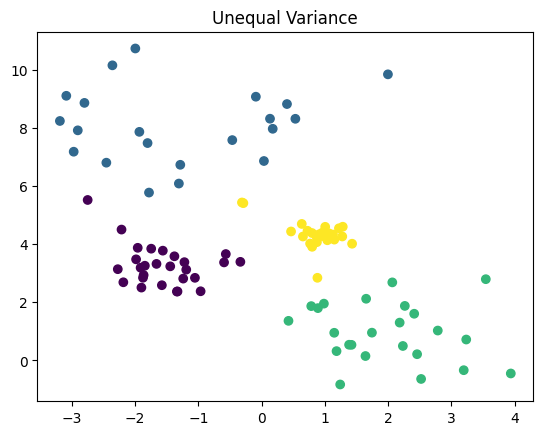

In [6]:
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_)
plt.title("Unequal Variance")